- MSSV: 25410291
- Họ Tên: Đinh Xuân Sâm
- GDrive: [IE313-b03.ipynb](https://colab.research.google.com/drive/1LgJnzm2BQD2M9Eki0RtwvnYS4QInn9CT?usp=sharing)


# Buổi 06 - Bài 05 - PHÂN TÍCH THĂM DÒ DỮ LIỆU

In [1]:
# import panda
import pandas as pd

In [2]:
# import matplotlib
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:
# import seaborn
import seaborn as sns

## 0. Load Dataset

### Data file

In [1]:
dataset_url = "https://raw.githubusercontent.com/datasethub/ds105/master/EDA_automobile.csv"
dataset_file = "EDA_automobile.csv"

In [2]:
# download the dataset file
import requests

response = requests.get(dataset_url)

with open(dataset_file, "wb") as file:
    file.write(response.content)

print("Download complete!")

Download complete!


### `read_csv`

In [6]:
# read from a local file
df = pd.read_csv(dataset_file)

In [7]:
df

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450,13.055556,Medium,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,std,four,sedan,rwd,front,109.1,0.907256,...,9.5,114.0,5400.0,23,28,16845,10.217391,Medium,0,1
197,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,0.907256,...,8.7,160.0,5300.0,19,25,19045,12.368421,High,0,1
198,-1,95,volvo,std,four,sedan,rwd,front,109.1,0.907256,...,8.8,134.0,5500.0,18,23,21485,13.055556,Medium,0,1
199,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,0.907256,...,23.0,106.0,4800.0,26,27,22470,9.038462,Medium,1,0


## 1. Phân Tích Thăm Dò Dữ Liệu

## Thống Kê Mô Tả

1. Hướng Trung Tâm (Central Tendency)
2. Độ Phân Tán (Dispersion)
3. Hình Dáng Dữ Liệu (Shape)
4. Tương Quan (Correlation)

### Central Tendency

### Dispersion

#### Quartitle

- Chia tập dữ liệu thành 4 phần có số lượng quan sát như nhau, mỗi phần có chứa khoảng 1/4, tức 25% giá trị.
- Cung cấp thông tin về các giá trị quan sát được phân bố từ Min tới Max.

In [10]:
s = pd.Series([1, 2, 3, 4])
s.quantile([0.25, 0.5, 0.75])

,0
0.25,1.75
0.50,2.50
0.75,3.25


In [12]:
price = df['price']

In [13]:
price.quantile([0.25, 0.5, 0.75])

,price
0.25,7775.0
0.50,10295.0
0.75,16500.0


<Axes: >

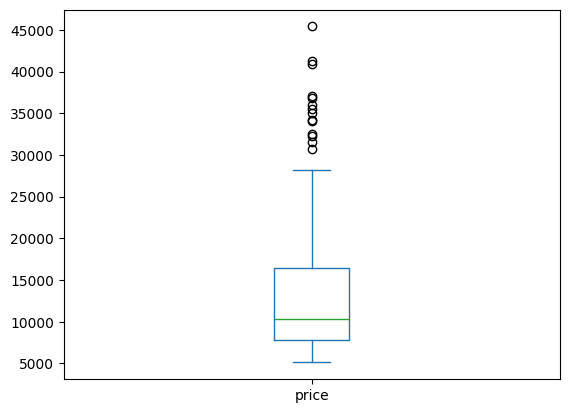

In [14]:
price.plot(kind='box')

<Axes: xlabel='drive-wheels', ylabel='price'>

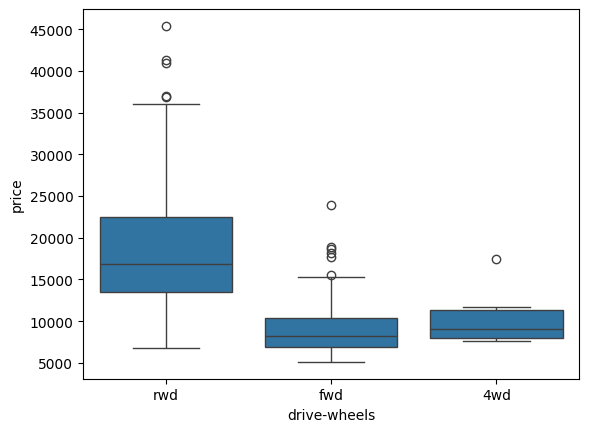

In [20]:
sns.boxplot(
    x="drive-wheels",
    y='price',
    data=df
)

<Axes: xlabel='drive-wheels', ylabel='price'>

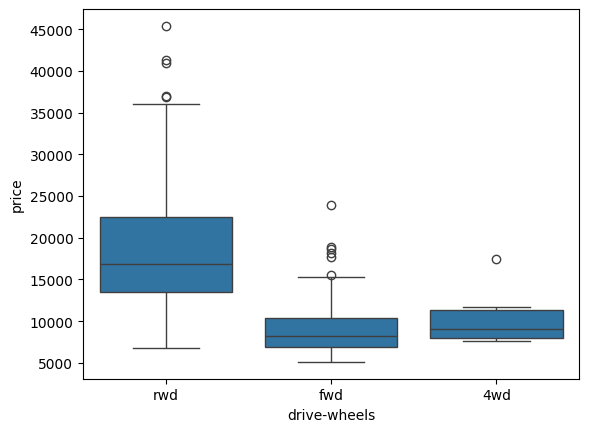

In [21]:
sns.boxplot(
    data = df,
    x="drive-wheels",
    y="price"
)

#### Bài Tập

- Vẽ boxplot biến `price` theo 2 cách: `Series.plot()` và `seaborn.boxplot()`.
- Tìm các mẫu dữ liệu khi biến `price` rơi vào ngoại lệ?
- Chọn chế độ thăm dò.

### Shape

#### Độ Lệch

<Axes: ylabel='Density'>

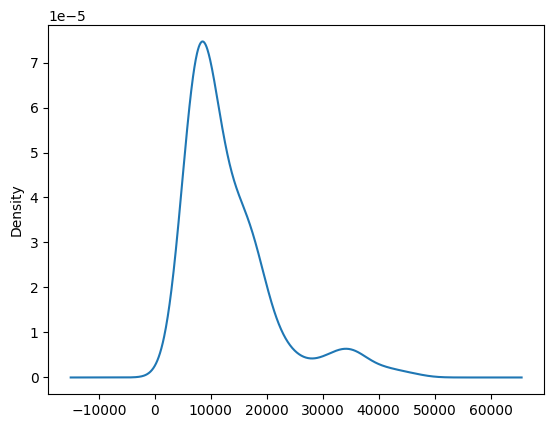

In [22]:
price.plot(kind='kde')

In [23]:
price.skew()

np.float64(1.8096753390980749)

<Axes: ylabel='Density'>

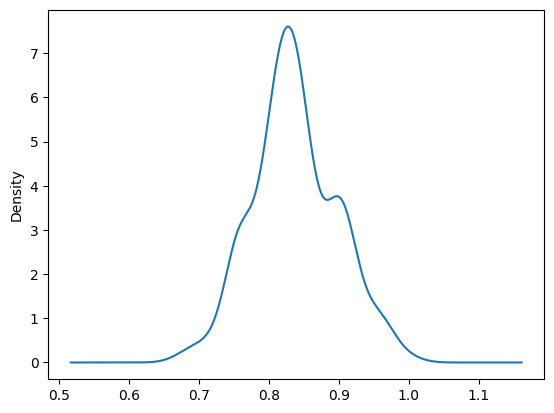

In [24]:
df['length'].plot(kind='kde')

In [25]:
df['length'].skew()

np.float64(0.15444634976972002)

#### Độ Cao (Kurtosis) Hay Độ Nhọn

In [26]:
df['length'].kurtosis()

np.float64(-0.06519162765593256)

#### Bài Tập

- Đánh giá biến `price` rơi vào ngoại lệ?
- Chọn từng biến (kiểu số) để thăm dò:
    - Lệch?
    - Cao?
    - Ngoại lệ?
    - vv..

### Độ Tương Quan (Corelation)

<Axes: xlabel='engine-size', ylabel='price'>

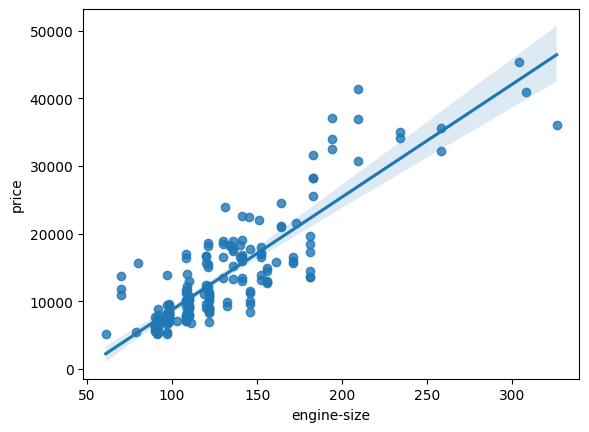

In [28]:
sns.regplot(
    data=df,
    x='engine-size',
    y='price'
)

<Axes: xlabel='highway-mpg', ylabel='price'>

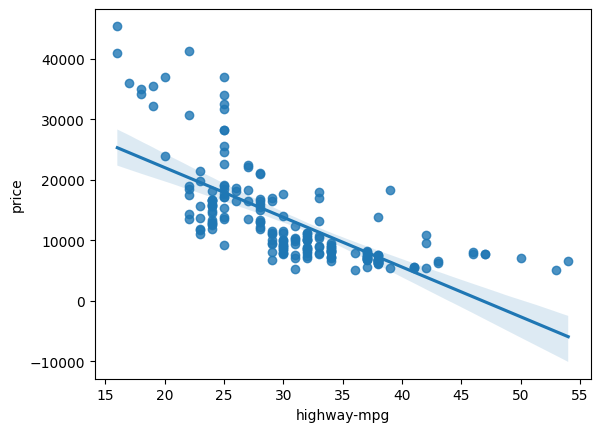

In [29]:
sns.regplot(
    data=df,
    x='highway-mpg',
    y='price'
)

<Axes: xlabel='peak-rpm', ylabel='price'>

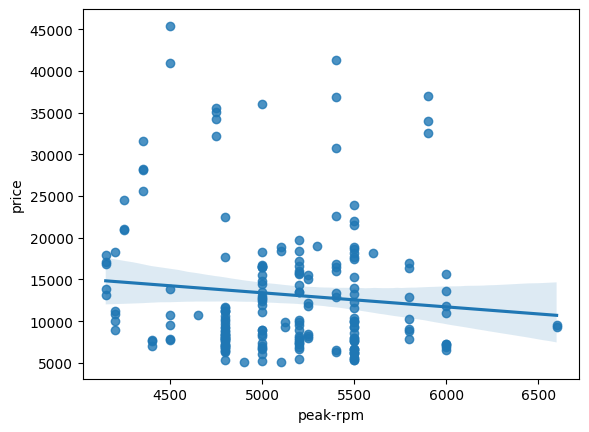

In [31]:
sns.regplot(
    data=df,
    x='peak-rpm',
    y='price'
)

Hệ số tương quan

| Độ | Đồng Thuận | Không Đồng Thuận |
|:--|:--|:--|
| Mạnh | 0.8 $\to$ 1 | -1 $\to$ -0.8|
| Vừa | 0.5 $\to$ 0.8 | -0.8 $\to$ -0.5 |
| Yếu | 0.3 $\to$ 0.5 | -0.5 $\to$ -0.3 |
| Không | 0 $\to$ 0.3 | -0.3 $\to$ 0 |

In [32]:
df['highway-mpg'].corr(df['price'])

np.float64(-0.704692265058953)

#### Hệ số tương quan Pearson

In [39]:
df[[
    'highway-mpg',
    'length',
    'engine-size',
    'price',
]].corr().round(3)

,highway-mpg,length,engine-size,price
highway-mpg,1.000,-0.698,-0.680,-0.705
length,-0.698,1.000,0.685,0.691
engine-size,-0.680,0.685,1.000,0.872
price,-0.705,0.691,0.872,1.000


<Axes: >

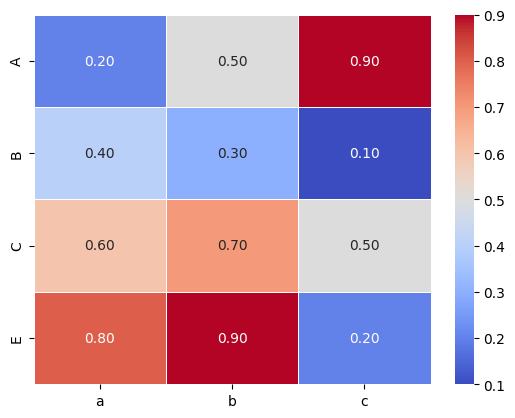

In [47]:
df_corr = pd.DataFrame(
    data={
        'a': [0.2, 0.4, 0.6, 0.8],
        'b': [0.5, 0.3, 0.7, 0.9],
        'c': [0.9, 0.1, 0.5, 0.2]
    },
    index=['A', 'B', 'C', 'E']
)

# plt.figure(figsize=(6, 4))

sns.heatmap(
    df_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=df_corr.columns,
    yticklabels=df_corr.index,
    linewidths=0.5
)

# plt.title("Matrix Heatmap (Seaborn)")
# plt.xlabel("Columns")
# plt.ylabel("Rows")
# plt.tight_layout()
# plt.show()

## Phân Tích Gom Nhóm Dữ Liệu Cơ Bản

- Giá trị phân loại.

#### Bài Tập

- Tr 63. Tìm xem hmake, engine, body style có khả năng giá xe thấp nhất?

## Phân Tích Phương Sai (ANOVA)

Trang 74

## Kết Luận

Công việc:

- Kích thước (size/shape).
- Ý nghĩa của từng trường/cột.
- Phân tích tham dò $\to$ Thống kê mô tả $\to$ Thăm dò từng biến.
- Đánh giá giá trị ngoại lệ.
- Xét độ tươgn quan (thống kê).
- Phân tích ANOVA.

$\Rightarrow$ trích xuất biến quan trọng ảnh hưởng đến mục tiêu.

## Bài Tập (tr 77)

- Sử dụng bộ dữ liệu giá xe.
- Chọn biến quan tọng ảnh hưởng đến giá xe.
